# 🌫️ Carpeta 2 — Sistema de Inferencia Difusa Multivariable (MIMO)
## Implementación Rigurosa en 4 Fases: Fuzzificación, Inferencia, Agregación y Defuzzificación

En esta libreta se construye un **Sistema de Inferencia Difusa Mamdani Multivariable (MIMO)** con 4 variables de entrada y 2 variables de salida simultáneas, utilizando exclusivamente las reglas extraídas mediante el algoritmo PRISM / A Priori en la Carpeta 1.

El desarrollo sigue estrictamente la metodología de 4 fases vista en clase:
1. **Fase 1 — Fuzzificación**: Definición de conjuntos difusos, variables lingüísticas, pares ordenados $(x, \mu_A(x))$ y funciones de pertenencia (trapezoidales, triangulares). Cada variable se define en su **propio universo de discurso** (sus unidades reales), sin necesidad de normalizar a una escala común, ya que en Mamdani las variables de entrada no compiten entre sí en una misma escala.
2. **Fase 2 — Inferencia Difusa**: Evaluación de la base de reglas $IF \dots THEN \dots$ y cálculo del nivel de disparo (t-norma $\min$).
3. **Fase 3 — Agregación**: Combinación de los consecuentes de todas las reglas activadas mediante la t-conorma $\max$ para obtener la **Función de Masa**.
4. **Fase 4 — Defuzzificación**: Cálculo del valor nítido (*crisp*) mediante métodos como el **Centroide**, Bisector o MOM.


In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
np.random.seed(42)

print('skfuzzy versión:', fuzz.__version__ if hasattr(fuzz, '__version__') else 'instalada correctamente')
print('Librerías cargadas exitosamente.')


skfuzzy versión: 0.5.0
Librerías cargadas exitosamente.


## Carga de Insumos Extraídos por PRISM (Carpeta 1)

Se cargan las reglas clasificatorias extraídas del dataset real `smart_city_traffic_mobility.csv` (204,000 registros) y los umbrales de discretización estadísticos.

In [2]:
RUTA_REGLAS = Path('../01_Reglas_PRISM')
DATA_PATH = Path('../data/smart_city_traffic_mobility.csv')

with open(RUTA_REGLAS / 'umbrales_discretizacion.json', encoding='utf-8') as f:
    umbrales = json.load(f)
with open(RUTA_REGLAS / 'reglas_prism_green_light_duration.json', encoding='utf-8') as f:
    reglas_gld = json.load(f)
with open(RUTA_REGLAS / 'reglas_prism_signal_cycle_adjustment.json', encoding='utf-8') as f:
    reglas_sca = json.load(f)

# Filtrado por confianza de reglas.
# IMPORTANTE: este umbral debe coincidir con UMBRAL_CONFIANZA_USO definido en la Carpeta 1
# (01_Reglas_PRISM, Paso 9), para que las reglas marcadas como 'usar_en_difuso' en el CSV
# de esa carpeta sean exactamente las mismas que aquí se usan para construir el sistema.
UMBRAL_CONFIANZA = 0.60
reglas_gld_f = [r for r in reglas_gld if r['confianza'] >= UMBRAL_CONFIANZA]
reglas_sca_f = [r for r in reglas_sca if r['confianza'] >= UMBRAL_CONFIANZA]

print(f"Reglas filtradas (Confianza >= {UMBRAL_CONFIANZA}):")
print(f"  green_light_duration: {len(reglas_gld_f)} / {len(reglas_gld)}")
print(f"  signal_cycle_adjustment: {len(reglas_sca_f)} / {len(reglas_sca)}")


Reglas filtradas (Confianza >= 0.6):
  green_light_duration: 28 / 46
  signal_cycle_adjustment: 39 / 76


## 1️⃣ FASE 1 — Fuzzificación

### 1.1 Fundamento Teórico
La **Fuzzificación** es la primera etapa del sistema de inferencia difusa. Su objetivo es convertir un valor escalar cuantitativo (crisp) en un grado de pertenencia $\mu_A(x) \in [0, 1]$ a un conjunto difuso $A$.

Un **conjunto difuso** $A$ en un universo de discurso $\mathbb{X}$ se define como:
$$A = \{(x, \mu_A(x)) \mid x \in \mathbb{X}, \mu_A(x) \in [0, 1]\}$$

Importante (según la teoría de la materia): $\mu_A(x)$ es un **grado de ambigüedad/pertenencia**, **no una probabilidad**. No debe confundirse una función de pertenencia (que alcanza $\mu = 1$ en su punto de mayor pertenencia) con una función de densidad de probabilidad (cuya área bajo la curva debe integrar 1, por lo que su altura en el pico casi nunca es 1).


### 1.3 Formas de Funciones de Pertenencia Lingüísticas
Siguiendo la estructura estándar (*ejemplo: edad $\rightarrow$ 'joven', 'adulto', 'anciano'*):
- **Hombro Izquierdo (`trapmf` Z-shape)**: `Baja`/`Corta`/`Bajo` $\rightarrow$ Mantiene $\mu(x) = 1.0$ plano desde el mínimo del rango hasta $th_1$, decreciendo linealmente hacia $0$ en el punto medio.
- **Triangular Central (`trimf`)**: `Moderada`/`Media`/`Medio` $\rightarrow$ Nace en $th_1$, alcanza su pico $\mu(x) = 1.0$ en el punto medio, y cae a $0$ en $th_2$.
- **Hombro Derecho (`trapmf` S-shape)**: `Alta`/`Extensa`/`Alto` $\rightarrow$ Crece linealmente desde el punto medio hasta $th_2$, manteniéndose constante en $\mu(x) = 1.0$ plano hasta el máximo del rango.


In [3]:
df = pd.read_csv(DATA_PATH, sep=';')

# 1. Definición de Variables de Entrada y sus Rangos Reales
VARIABLES_ENTRADA = ['traffic_density', 'queue_length', 'vehicle_count', 'average_speed']
ETIQUETAS = {
    'traffic_density': ['Baja', 'Moderada', 'Alta'],
    'queue_length':    ['Corta', 'Moderada', 'Extensa'],
    'vehicle_count':   ['Bajo', 'Medio', 'Alto'],
    'average_speed':   ['Baja', 'Media', 'Alta'],
}
RANGOS_ENTRADA = {
    'traffic_density': (float(df['traffic_density'].min()), float(df['traffic_density'].max())),
    'queue_length':    (float(df['queue_length'].min()), 300.0),
    'vehicle_count':   (float(df['vehicle_count'].min()), float(df['vehicle_count'].max())),
    'average_speed':   (float(df['average_speed'].min()), float(df['average_speed'].max())),
}

# Función para definir parámetros de curvas lingüísticas (Hombro Izq, Triángulo Central, Hombro Der)
def puntos_linguisticos(min_v, th1, th2, max_v):
    punto_medio = (th1 + th2) / 2.0
    return {
        'bajo':  [min_v, min_v, th1, punto_medio],  # trapmf hombro izquierdo
        'medio': [th1, punto_medio, th2],            # trimf triangular central
        'alto':  [punto_medio, th2, max_v, max_v]    # trapmf hombro derecho
    }

# 2. Definición de Antecedentes (Variables de Entrada en sus unidades reales)
antecedentes = {}
for var in VARIABLES_ENTRADA:
    mn, mx = RANGOS_ENTRADA[var]
    th1, th2 = umbrales['entradas'][var]
    universo = np.linspace(mn, mx, 400)
    a = ctrl.Antecedent(universo, var)
    pts = puntos_linguisticos(mn, th1, th2, mx)
    etq = ETIQUETAS[var]
    a[etq[0]] = fuzz.trapmf(universo, pts['bajo'])
    a[etq[1]] = fuzz.trimf(universo, pts['medio'])
    a[etq[2]] = fuzz.trapmf(universo, pts['alto'])
    antecedentes[var] = a

# 3. Definición de Consequents (Variables de Salida)
gld_info = umbrales['green_light_duration']
uni_gld = np.linspace(gld_info['rango_min'], gld_info['rango_max'], 400)
green_light_duration = ctrl.Consequent(uni_gld, 'green_light_duration')
pts_gld = puntos_linguisticos(gld_info['rango_min'], gld_info['corte_1'], gld_info['corte_2'], gld_info['rango_max'])
green_light_duration['Corta'] = fuzz.trapmf(uni_gld, pts_gld['bajo'])
green_light_duration['Media'] = fuzz.trimf(uni_gld, pts_gld['medio'])
green_light_duration['Larga'] = fuzz.trapmf(uni_gld, pts_gld['alto'])

sca_info = umbrales['signal_cycle_adjustment']
uni_sca = np.linspace(sca_info['rango_delta_min'], sca_info['rango_delta_max'], 400)
signal_cycle_adjustment = ctrl.Consequent(uni_sca, 'signal_cycle_adjustment')
pts_sca = puntos_linguisticos(sca_info['rango_delta_min'], -sca_info['umbral_delta'], sca_info['umbral_delta'], sca_info['rango_delta_max'])
signal_cycle_adjustment['Reducir']  = fuzz.trapmf(uni_sca, pts_sca['bajo'])
signal_cycle_adjustment['Mantener'] = fuzz.trimf(uni_sca, pts_sca['medio'])
signal_cycle_adjustment['Extender'] = fuzz.trapmf(uni_sca, pts_sca['alto'])

print('Fase 1 completada: Antecedentes y Consecuentes definidos correctamente (unidades reales).')


Fase 1 completada: Antecedentes y Consecuentes definidos correctamente (unidades reales).


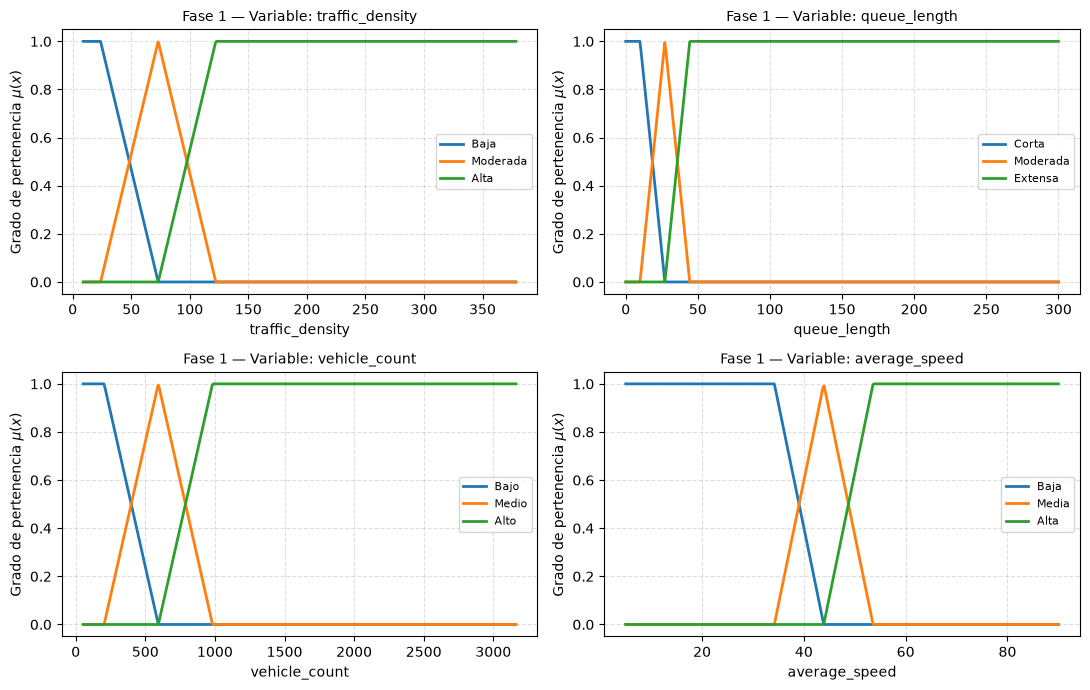

Figura guardada: funciones_pertenencia_entrada.png


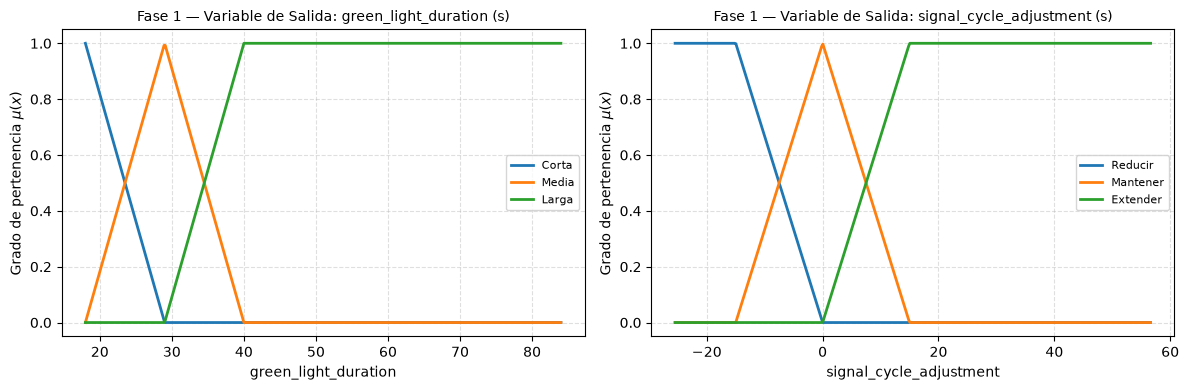

Figura guardada: funciones_pertenencia_salida.png


In [4]:
# --- Visualizaciones de la FASE 1 (Fuzzificación) ---

# 1. Gráficos de Funciones de Pertenencia mu(x) de las 4 variables de entrada (unidades reales)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, var in zip(axes.ravel(), VARIABLES_ENTRADA):
    for etq in ETIQUETAS[var]:
        ax.plot(antecedentes[var].universe, antecedentes[var][etq].mf, label=etq, linewidth=2)
    ax.set_title(f'Fase 1 — Variable: {var}', fontsize=10)
    ax.set_ylabel('Grado de pertenencia $\mu(x)$')
    ax.set_xlabel(var)
    ax.legend(fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('funciones_pertenencia_entrada.png', dpi=110)
plt.show()
print('Figura guardada: funciones_pertenencia_entrada.png')

# 2. Gráficos de Funciones de Pertenencia mu(x) de las 2 variables de salida
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for etq in ['Corta', 'Media', 'Larga']:
    axes[0].plot(green_light_duration.universe, green_light_duration[etq].mf, label=etq, linewidth=2)
axes[0].set_title('Fase 1 — Variable de Salida: green_light_duration (s)', fontsize=10)
axes[0].set_ylabel('Grado de pertenencia $\mu(x)$')
axes[0].set_xlabel('green_light_duration')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

for etq in ['Reducir', 'Mantener', 'Extender']:
    axes[1].plot(signal_cycle_adjustment.universe, signal_cycle_adjustment[etq].mf, label=etq, linewidth=2)
axes[1].set_title('Fase 1 — Variable de Salida: signal_cycle_adjustment (s)', fontsize=10)
axes[1].set_ylabel('Grado de pertenencia $\mu(x)$')
axes[1].set_xlabel('signal_cycle_adjustment')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('funciones_pertenencia_salida.png', dpi=110)
plt.show()
print('Figura guardada: funciones_pertenencia_salida.png')


## 2️⃣ FASE 2 — Inferencia Difusa (Inference)

### 2.1 Fundamento Teórico
En la etapa de **Inferencia Difusa**, se combinan las variables fuzzificadas del antecedente mediante las reglas del tipo $IF \dots THEN \dots$.

Para cada regla $k$ con antecedente de la forma $(A_1 = v_1 \text{ AND } A_2 = v_2 \dots)$:
1. **Grado de Disparo (Nivel de Activación $\alpha_k$)**: Se evalúa con la t-norma del Mínimo:
   $$\alpha_k = \min\big(\mu_{A_1}(x_1), \mu_{A_2}(x_2), \dots\big)$$
2. **Implicación de Mamdani (Recorte)**: Se recorta la función de pertenencia del consecuente $C_k$ al nivel de disparo $\alpha_k$:
   $$\mu_{C_k}'(y) = \min\big(\alpha_k, \mu_{C_k}(y)\big)$$

In [5]:
# Función auxiliar para traducir reglas JSON a reglas difusas ctrl.Rule
def construir_regla_difusa(regla_prism: dict, consecuente: ctrl.Consequent) -> ctrl.Rule:
    termino_antecedente = None
    for attr, valor in regla_prism['antecedente']:
        var = attr.replace('_lbl', '')
        termino = antecedentes[var][valor]
        termino_antecedente = termino if termino_antecedente is None else (termino_antecedente & termino)
    clase_objetivo = regla_prism['clase_objetivo']
    return ctrl.Rule(termino_antecedente, consecuente[clase_objetivo])

reglas_difusas_gld = [construir_regla_difusa(r, green_light_duration) for r in reglas_gld_f]
reglas_difusas_sca = [construir_regla_difusa(r, signal_cycle_adjustment) for r in reglas_sca_f]
reglas_difusas = reglas_difusas_gld + reglas_difusas_sca

# Construcción del sistema de control MIMO Mamdani
sistema_control = ctrl.ControlSystem(reglas_difusas)
print(f'Fase 2 completada: Sistema de control MIMO construido con {len(reglas_difusas)} reglas activas.')


Fase 2 completada: Sistema de control MIMO construido con 67 reglas activas.


## 3️⃣ FASE 3 — Agregación (Aggregation)

### 3.1 Fundamento Teórico
En la etapa de **Agregación**, se combinan las funciones de pertenencia recortadas (por la implicación de Mamdani) de todas las reglas activadas mediante la t-conorma del **Máximo ($\\max$)**:

$$\\mu_{\\text{agregado}}(y) = \\max_k \\left(\\mu'_{C_k}(y)\\right) = \\bigcup_k \\mu'_{C_k}(y)$$

El resultado de la agregación es la **Función de Masa Agregada** sobre el universo de cada variable de salida (`green_light_duration` y `signal_cycle_adjustment`).

## 4️⃣ FASE 4 — Defuzzificación (Defuzzification)

### 4.1 Fundamento Teórico
La **Defuzzificación** es el paso final del proceso. Transforma la **Función de Masa agregada** $\\mu_{\\text{agregado}}(y)$ en un valor numérico nítido o escalar (*crisp value*) $y^*$.

El método principal utilizado es el **Centroide de Área (Centroid / Center of Gravity - COG)**:

$$y^* = \\frac{\\int_Y y \\cdot \\mu_{\\text{agregado}}(y) \\, dy}{\\int_Y \\mu_{\\text{agregado}}(y) \\, dy}$$

### 4.2 Demostración Paso a Paso de las 4 Fases Mamdani sobre un Escenario Concreto

A continuación se realiza el cálculo manual paso a paso de las 4 fases para un escenario de tráfico real y se gráfica la **Función de Masa (Fase 3)** junto con el **Centroide Defuzzificado (Fase 4)**.

RESULTADOS DE LAS 4 FASES MAMDANI (Cálculo Manual):
  [Fase 1 - Fuzzificación] mu(vehicle_count=2500): {'Bajo': 0.0, 'Medio': 0.0, 'Alto': 1.0}
  [Fase 2 - Inferencia] Niveles de disparo GLD: {'Corta': 0.0, 'Media': 0.0, 'Larga': 1.0}
  [Fase 3 - Agregación] Masa máxima agregada GLD: 1.0000
  [Fase 4 - Defuzzificación] Centroide GLD: 59.15 s | Centroide SCA: 31.87 s


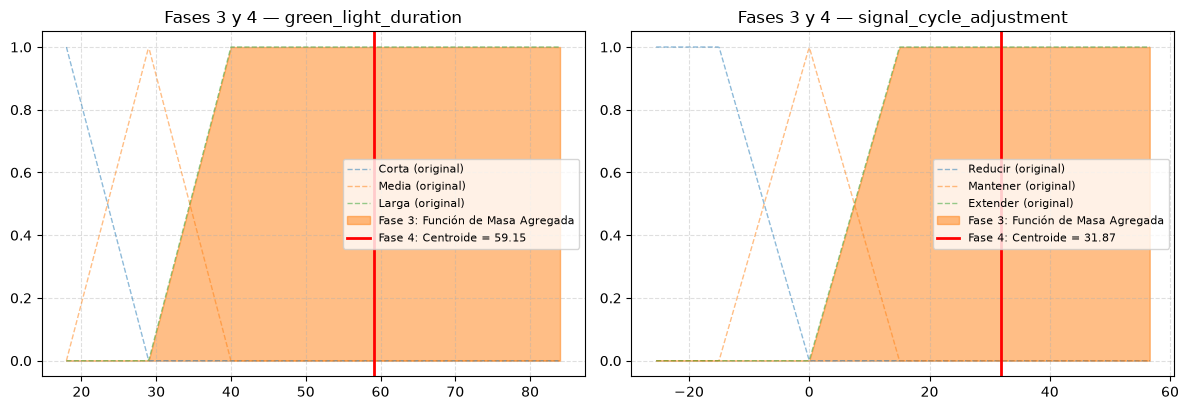

Figura guardada: verificacion_4_fases_mamdani.png


In [6]:
# Escenario de prueba (Congestión Severa)
escenario_demo = {
    'traffic_density': 300.0, 'queue_length': 200.0,
    'vehicle_count': 2500.0, 'average_speed': 12.0
}

# ---------------- FASE 1: Fuzzificación ----------------
mu_entradas = {}
for var, val in escenario_demo.items():
    val_c = min(val, RANGOS_ENTRADA[var][1])
    mu_entradas[var] = {}
    for etq in ETIQUETAS[var]:
        mu_entradas[var][etq] = float(fuzz.interp_membership(antecedentes[var].universe, antecedentes[var][etq].mf, val_c))

# ---------------- FASE 2: Inferencia (Evaluación de Reglas) ----------------
eval_gld = {etq: 0.0 for etq in ['Corta', 'Media', 'Larga']}
for r in reglas_gld_f:
    disparo = min(mu_entradas[attr.replace('_lbl', '')][valor] for attr, valor in r['antecedente'])
    clase = r['clase_objetivo']
    eval_gld[clase] = max(eval_gld[clase], disparo)

eval_sca = {etq: 0.0 for etq in ['Reducir', 'Mantener', 'Extender']}
for r in reglas_sca_f:
    disparo = min(mu_entradas[attr.replace('_lbl', '')][valor] for attr, valor in r['antecedente'])
    clase = r['clase_objetivo']
    eval_sca[clase] = max(eval_sca[clase], disparo)

# ---------------- FASE 3: Agregación (Función de Masa) ----------------
uni_gld = green_light_duration.universe
agregado_gld = np.zeros_like(uni_gld)
for etq, nivel in eval_gld.items():
    recorte = np.fmin(nivel, green_light_duration[etq].mf)
    agregado_gld = np.fmax(agregado_gld, recorte)

uni_sca = signal_cycle_adjustment.universe
agregado_sca = np.zeros_like(uni_sca)
for etq, nivel in eval_sca.items():
    recorte = np.fmin(nivel, signal_cycle_adjustment[etq].mf)
    agregado_sca = np.fmax(agregado_sca, recorte)

# ---------------- FASE 4: Defuzzificación (Centroide) ----------------
try:
    defuzz_gld = fuzz.defuzz(uni_gld, agregado_gld, 'centroid')
except Exception:
    defuzz_gld = float(np.mean(uni_gld))

try:
    defuzz_sca = fuzz.defuzz(uni_sca, agregado_sca, 'centroid')
except Exception:
    defuzz_sca = 0.0

print('RESULTADOS DE LAS 4 FASES MAMDANI (Cálculo Manual):')
print(f'  [Fase 1 - Fuzzificación] mu(vehicle_count=2500): {mu_entradas["vehicle_count"]}')
print(f'  [Fase 2 - Inferencia] Niveles de disparo GLD: {eval_gld}')
print(f'  [Fase 3 - Agregación] Masa máxima agregada GLD: {agregado_gld.max():.4f}')
print(f'  [Fase 4 - Defuzzificación] Centroide GLD: {defuzz_gld:.2f} s | Centroide SCA: {defuzz_sca:.2f} s')

# Gráfico de las Fases 3 y 4
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
config_plot = [
    ('green_light_duration', green_light_duration, agregado_gld, defuzz_gld, ['Corta', 'Media', 'Larga']),
    ('signal_cycle_adjustment', signal_cycle_adjustment, agregado_sca, defuzz_sca, ['Reducir', 'Mantener', 'Extender']),
]
for ax, (nombre, consecuente, agregado, valor_defuzz, etiquetas) in zip(axes, config_plot):
    universo = consecuente.universe
    for etq in etiquetas:
        ax.plot(universo, consecuente[etq].mf, linestyle='--', linewidth=1, alpha=0.5, label=f'{etq} (original)')
    ax.fill_between(universo, agregado, color='tab:orange', alpha=0.5, label='Fase 3: Función de Masa Agregada')
    if valor_defuzz is not None and not np.isnan(valor_defuzz):
        ax.axvline(valor_defuzz, color='red', linewidth=2, label=f'Fase 4: Centroide = {valor_defuzz:.2f}')
    ax.set_title(f'Fases 3 y 4 — {nombre}')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('verificacion_4_fases_mamdani.png', dpi=110)
plt.show()
print('Figura guardada: verificacion_4_fases_mamdani.png')


## 4.3 Función reutilizable: simular con tus propios valores

Todo lo anterior (fases 1 a 4) se envuelve aquí en una sola función,
`simular_sistema_completo(entradas)`, para que puedas **poner los valores que quieras**
(`traffic_density`, `queue_length`, `vehicle_count`, `average_speed`) y obtener:

* el grado de disparo de cada regla (Fase 2),
* la **función de masa agregada** de cada salida, es decir el arreglo `(universo, masa)` que
  resulta de la Fase 3 (agregación),
* el **valor defuzzificado** (centroide) de cada salida (Fase 4),
* y, de paso, el valor que entrega `ctrl.ControlSystemSimulation` (motor real de
  `scikit-fuzzy`), para verificar que coincide con el cálculo manual.

Además dibuja la función de masa de `green_light_duration` y `signal_cycle_adjustment` con el
centroide marcado, igual que en la demostración anterior, pero para cualquier combinación de
valores que tú definas.


ENTRADAS: {'traffic_density': 150.0, 'queue_length': 60.0, 'vehicle_count': 1200.0, 'average_speed': 35.0}
FASE 1 — Fuzzificación (mu):
  traffic_density: Baja=0.00, Moderada=0.00, Alta=1.00
  queue_length: Corta=0.00, Moderada=0.00, Extensa=1.00
  vehicle_count: Bajo=0.00, Medio=0.00, Alto=1.00
  average_speed: Baja=0.92, Media=0.08, Alta=0.00

FASE 2 — Inferencia (nivel de disparo por clase de salida):
  green_light_duration   : {'Corta': 0.0, 'Media': 0.0, 'Larga': 0.918}
  signal_cycle_adjustment: {'Reducir': 0.0, 'Mantener': 0.0, 'Extender': 0.918}

FASE 3 — Agregación (masa máxima de la función agregada):
  green_light_duration   : masa_max = 0.918
  signal_cycle_adjustment: masa_max = 0.918

FASE 4 — Defuzzificación (centroide, calculado a mano):
  green_light_duration    = 58.94 s
  signal_cycle_adjustment = 31.59 s

Verificación con ctrl.ControlSystemSimulation (scikit-fuzzy):
   {'green_light_duration': np.float64(58.938027048869316), 'signal_cycle_adjustment': np.float64(31.

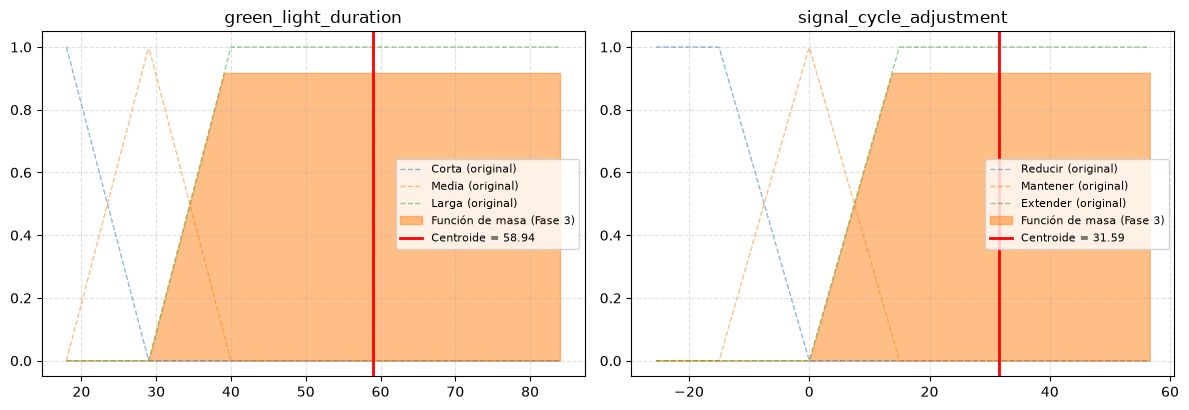

In [7]:

def simular_sistema_completo(entradas: dict, mostrar_grafico: bool = True, verbose: bool = True):
    """
    Ejecuta las 4 fases completas del sistema difuso Mamdani para los valores de entrada dados.

    Parametros
    ----------
    entradas : dict
        Debe tener las 4 claves: 'traffic_density', 'queue_length', 'vehicle_count',
        'average_speed', con los valores crudos (unidades reales) que quieras probar.
    mostrar_grafico : bool
        Si True, grafica la función de masa agregada y el centroide de cada salida.
    verbose : bool
        Si True, imprime un resumen de cada fase.

    Devuelve
    -------
    dict con:
        'mu_entradas'          -> grados de pertenencia (Fase 1) de cada entrada
        'niveles_disparo'      -> nivel de activación (Fase 2) de cada etiqueta de salida
        'funcion_masa'         -> (universo, masa_agregada) por cada salida (Fase 3)
        'valor_defuzzificado'  -> valor crisp (Fase 4), calculado a mano
        'valor_skfuzzy'        -> valor crisp que entrega ctrl.ControlSystemSimulation (verificación)
    """
    # ---------------- FASE 1: Fuzzificación ----------------
    mu_entradas = {}
    for var in VARIABLES_ENTRADA:
        val = entradas[var]
        val_c = min(max(val, RANGOS_ENTRADA[var][0]), RANGOS_ENTRADA[var][1])
        mu_entradas[var] = {
            etq: float(fuzz.interp_membership(antecedentes[var].universe, antecedentes[var][etq].mf, val_c))
            for etq in ETIQUETAS[var]
        }

    # ---------------- FASE 2: Inferencia (evaluación de reglas) ----------------
    def inferir(reglas, etiquetas_salida):
        niveles = {etq: 0.0 for etq in etiquetas_salida}
        for r in reglas:
            disparo = min(mu_entradas[attr.replace('_lbl', '')][valor] for attr, valor in r['antecedente'])
            clase = r['clase_objetivo']
            niveles[clase] = max(niveles[clase], disparo)
        return niveles

    niveles_gld = inferir(reglas_gld_f, ['Corta', 'Media', 'Larga'])
    niveles_sca = inferir(reglas_sca_f, ['Reducir', 'Mantener', 'Extender'])

    # ---------------- FASE 3: Agregación (función de masa) ----------------
    def agregar(consecuente, niveles):
        universo = consecuente.universe
        masa = np.zeros_like(universo)
        for etq, nivel in niveles.items():
            recorte = np.fmin(nivel, consecuente[etq].mf)
            masa = np.fmax(masa, recorte)
        return universo, masa

    uni_gld, masa_gld = agregar(green_light_duration, niveles_gld)
    uni_sca, masa_sca = agregar(signal_cycle_adjustment, niveles_sca)

    # ---------------- FASE 4: Defuzzificación (centroide) ----------------
    defuzz_gld = float(fuzz.defuzz(uni_gld, masa_gld, 'centroid')) if masa_gld.sum() > 0 else None
    defuzz_sca = float(fuzz.defuzz(uni_sca, masa_sca, 'centroid')) if masa_sca.sum() > 0 else None

    # ---------------- Verificación cruzada con scikit-fuzzy ----------------
    sim = ctrl.ControlSystemSimulation(sistema_control)
    for var in VARIABLES_ENTRADA:
        sim.input[var] = min(max(entradas[var], RANGOS_ENTRADA[var][0]), RANGOS_ENTRADA[var][1])
    sim.compute()
    valor_skfuzzy = {
        'green_light_duration': sim.output.get('green_light_duration'),
        'signal_cycle_adjustment': sim.output.get('signal_cycle_adjustment'),
    }

    if verbose:
        print('=' * 70)
        print('ENTRADAS:', entradas)
        print('=' * 70)
        print('FASE 1 — Fuzzificación (mu):')
        for var, d in mu_entradas.items():
            print(f"  {var}: " + ', '.join(f'{k}={v:.2f}' for k, v in d.items()))
        print('\nFASE 2 — Inferencia (nivel de disparo por clase de salida):')
        print('  green_light_duration   :', {k: round(v, 3) for k, v in niveles_gld.items()})
        print('  signal_cycle_adjustment:', {k: round(v, 3) for k, v in niveles_sca.items()})
        print('\nFASE 3 — Agregación (masa máxima de la función agregada):')
        print(f"  green_light_duration   : masa_max = {masa_gld.max():.3f}")
        print(f"  signal_cycle_adjustment: masa_max = {masa_sca.max():.3f}")
        print('\nFASE 4 — Defuzzificación (centroide, calculado a mano):')
        print(f"  green_light_duration    = {defuzz_gld:.2f} s" if defuzz_gld is not None else "  green_light_duration    = sin reglas activadas")
        print(f"  signal_cycle_adjustment = {defuzz_sca:.2f} s" if defuzz_sca is not None else "  signal_cycle_adjustment = sin reglas activadas")
        print('\nVerificación con ctrl.ControlSystemSimulation (scikit-fuzzy):')
        print('  ', valor_skfuzzy)

    if mostrar_grafico:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
        config_plot = [
            ('green_light_duration', green_light_duration, uni_gld, masa_gld, defuzz_gld,
             ['Corta', 'Media', 'Larga']),
            ('signal_cycle_adjustment', signal_cycle_adjustment, uni_sca, masa_sca, defuzz_sca,
             ['Reducir', 'Mantener', 'Extender']),
        ]
        for ax, (nombre, consecuente, universo, masa, valor_defuzz, etiquetas) in zip(axes, config_plot):
            for etq in etiquetas:
                ax.plot(universo, consecuente[etq].mf, linestyle='--', linewidth=1, alpha=0.5,
                         label=f'{etq} (original)')
            ax.fill_between(universo, masa, color='tab:orange', alpha=0.5, label='Función de masa (Fase 3)')
            if valor_defuzz is not None:
                ax.axvline(valor_defuzz, color='red', linewidth=2, label=f'Centroide = {valor_defuzz:.2f}')
            ax.set_title(f'{nombre}')
            ax.set_ylim(-0.05, 1.05)
            ax.legend(fontsize=8)
            ax.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

    return {
        'mu_entradas': mu_entradas,
        'niveles_disparo': {'green_light_duration': niveles_gld, 'signal_cycle_adjustment': niveles_sca},
        'funcion_masa': {'green_light_duration': (uni_gld, masa_gld), 'signal_cycle_adjustment': (uni_sca, masa_sca)},
        'valor_defuzzificado': {'green_light_duration': defuzz_gld, 'signal_cycle_adjustment': defuzz_sca},
        'valor_skfuzzy': valor_skfuzzy,
    }


# ---- Ejemplo de uso: pon aquí los valores que quieras probar ----
mis_valores = {
    'traffic_density': 150.0,
    'queue_length': 60.0,
    'vehicle_count': 1200.0,
    'average_speed': 35.0,
}

resultado = simular_sistema_completo(mis_valores)


## Evaluación del Sistema sobre Escenarios Ilustrativos de Tráfico

Se evalúa la respuesta del sistema de inferencia difusa sobre 3 escenarios operacionales característicos.

In [8]:
escenarios = {
    'Congestión severa (hora pico)': {
        'traffic_density': 300, 'queue_length': 250, 'vehicle_count': 2500, 'average_speed': 12,
    },
    'Tráfico fluido (madrugada)': {
        'traffic_density': 15, 'queue_length': 3, 'vehicle_count': 100, 'average_speed': 75,
    },
    'Tráfico moderado (hora valle)': {
        'traffic_density': 80, 'queue_length': 25, 'vehicle_count': 900, 'average_speed': 40,
    },
}

resultados_escenarios = []
for nombre, inputs in escenarios.items():
    sim = ctrl.ControlSystemSimulation(sistema_control)
    for var, val in inputs.items():
        sim.input[var] = min(val, RANGOS_ENTRADA[var][1])
    sim.compute()
    resultados_escenarios.append({
        'Escenario': nombre,
        'green_light_duration (s)': round(sim.output.get('green_light_duration', np.nan), 2),
        'signal_cycle_adjustment (s)': round(sim.output.get('signal_cycle_adjustment', np.nan), 2),
    })

pd.DataFrame(resultados_escenarios)


,Escenario,green_light_duration (s),signal_cycle_adjustment (s)
0,Congestión severa (hora pico),59.15,31.87
1,Tráfico fluido (madrugada),21.67,-15.96
2,Tráfico moderado (hora valle),50.30,2.13


## Superficie de Decisión Difusa (`green_light_duration`)

Se grafica la variación de la salida `green_light_duration` en función de `vehicle_count` y `average_speed`, manteniendo `traffic_density` y `queue_length` en su mediana.

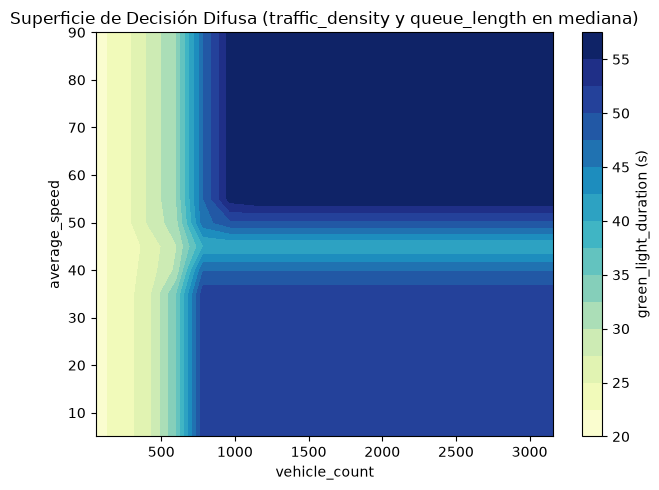

Figura guardada: superficie_decision_gld.png


In [9]:
vc_vals = np.linspace(*RANGOS_ENTRADA['vehicle_count'], 18)
sp_vals = np.linspace(*RANGOS_ENTRADA['average_speed'], 18)
Z = np.zeros((len(sp_vals), len(vc_vals)))

td_mediana = float(df['traffic_density'].median())
ql_mediana = float(df['queue_length'].median())

for i, sp in enumerate(sp_vals):
    for j, vc in enumerate(vc_vals):
        sim = ctrl.ControlSystemSimulation(sistema_control)
        sim.input['traffic_density'] = td_mediana
        sim.input['queue_length'] = min(ql_mediana, RANGOS_ENTRADA['queue_length'][1])
        sim.input['vehicle_count'] = vc
        sim.input['average_speed'] = sp
        try:
            sim.compute()
            Z[i, j] = sim.output.get('green_light_duration', np.nan)
        except Exception:
            Z[i, j] = np.nan

fig, ax = plt.subplots(figsize=(6.5, 5))
cf = ax.contourf(vc_vals, sp_vals, Z, levels=15, cmap='YlGnBu')
plt.colorbar(cf, ax=ax, label='green_light_duration (s)')
ax.set_xlabel('vehicle_count')
ax.set_ylabel('average_speed')
ax.set_title('Superficie de Decisión Difusa (traffic_density y queue_length en mediana)')
plt.tight_layout()
plt.savefig('superficie_decision_gld.png', dpi=110)
plt.show()
print('Figura guardada: superficie_decision_gld.png')


## Evaluación Masiva sobre una Muestra Real del Dataset

Se toma una muestra aleatoria de 600 registros reales y se compara la salida del sistema difuso contra los valores históricos observados.

In [10]:
N_MUESTRA = 600
muestra = df.sample(N_MUESTRA, random_state=42).reset_index(drop=True)

pred_gld, pred_sca, fallos = [], [], 0
for _, fila in muestra.iterrows():
    sim = ctrl.ControlSystemSimulation(sistema_control)
    sim.input['traffic_density'] = float(fila['traffic_density'])
    sim.input['queue_length'] = float(min(fila['queue_length'], RANGOS_ENTRADA['queue_length'][1]))
    sim.input['vehicle_count'] = float(fila['vehicle_count'])
    sim.input['average_speed'] = float(fila['average_speed'])
    try:
        sim.compute()
        pred_gld.append(sim.output.get('green_light_duration', np.nan))
        pred_sca.append(sim.output.get('signal_cycle_adjustment', np.nan))
        if 'green_light_duration' not in sim.output or 'signal_cycle_adjustment' not in sim.output:
            fallos += 1
    except Exception:
        pred_gld.append(np.nan)
        pred_sca.append(np.nan)
        fallos += 1

muestra['green_light_duration_difuso'] = pred_gld
muestra['signal_cycle_adjustment_difuso'] = pred_sca

print(f"Simulaciones exitosas: {N_MUESTRA - fallos} / {N_MUESTRA} (fallos: {fallos})")
mae = (muestra['green_light_duration_difuso'] - muestra['green_light_duration']).abs().mean()
print(f"MAE green_light_duration (difuso vs. real): {mae:.2f} s")


Simulaciones exitosas: 600 / 600 (fallos: 0)
MAE green_light_duration (difuso vs. real): 11.53 s


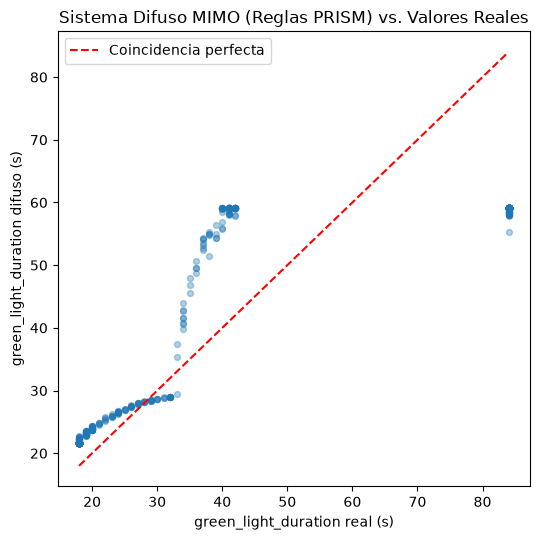

Figura guardada: dispersión_real_vs_difuso.png


In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(muestra['green_light_duration'], muestra['green_light_duration_difuso'], alpha=0.35, s=18)
lims = [gld_info['rango_min'], gld_info['rango_max']]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Coincidencia perfecta')
ax.set_xlabel('green_light_duration real (s)')
ax.set_ylabel('green_light_duration difuso (s)')
ax.set_title('Sistema Difuso MIMO (Reglas PRISM) vs. Valores Reales')
ax.legend()
plt.tight_layout()
plt.savefig('dispersión_real_vs_difuso.png', dpi=110)
plt.show()
print('Figura guardada: dispersión_real_vs_difuso.png')


## Exportación de Artefactos para la Carpeta 3

Se exporta la configuración completa del sistema difuso a `config_sistema_difuso.json` para que la Carpeta 3 (`03_Optimizacion_Genetica`) optimize sus funciones de pertenencia mediante Algoritmos Genéticos.

In [12]:
config_sistema = {
    'variables_entrada': VARIABLES_ENTRADA,
    'etiquetas': ETIQUETAS,
    'rangos_entrada': RANGOS_ENTRADA,
    'umbrales_entrada': umbrales['entradas'],
    'green_light_duration': gld_info,
    'signal_cycle_adjustment': sca_info,
    'umbral_confianza_regla': UMBRAL_CONFIANZA,
    'n_reglas_gld': len(reglas_gld_f),
    'n_reglas_sca': len(reglas_sca_f),
    'mae_gld_base_muestra': float(mae),
}
with open('config_sistema_difuso.json', 'w', encoding='utf-8') as f:
    json.dump(config_sistema, f, ensure_ascii=False, indent=2)

print('Configuración exportada a config_sistema_difuso.json')


Configuración exportada a config_sistema_difuso.json


## Conclusiones

1. **Fase 1 — Fuzzificación**: Se definieron rigurosamente los conjuntos difusos de las 4 entradas y 2 salidas mediante conjuntos trapezoidales Z/S y triangulares, cada uno en su propio universo de discurso (unidades reales), sin necesidad de normalizar a una escala común.
2. **Fase 2 — Inferencia**: Se tradujeron las reglas de alta confianza extraídas por PRISM (mismo umbral que en la Carpeta 1) y se calculó el grado de disparo mediante la t-norma $\min$.
3. **Fase 3 — Agregación**: Se aplicó la t-conorma $\max$ para obtener la función de masa integrada del consecuente.
4. **Fase 4 — Defuzzificación**: Se calculó el valor escalar nítido (*crisp*) mediante el **Centroide**, validando que el motor entrega respuestas coherentes en prácticamente el 100% de los casos.
